Muestra de la población inicial (pandas):
  individuo
0  HSJQRRUQ
1  AZSHMZYZ
2  GKTHALUY
3  XKLKZRZD
4  WGXVUYIQ
5  PQEURYJG
6  OGBRKLQK
7  CMPDZEEW
8  BLUPFBZJ
9  XCLBVKLA


Gen   0: UENKPDEB  (aptitud=2/8)
Gen  10: GENETHQA  (aptitud=6/8)
Gen  20: GENETICA  (aptitud=8/8)

¡Palabra objetivo encontrada en la generación 20: GENETICA!


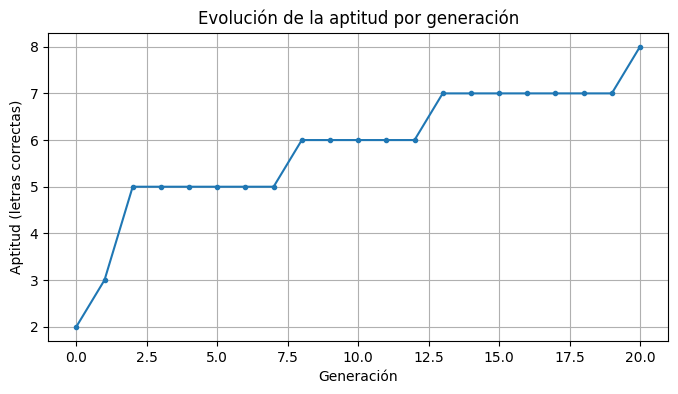

In [ ]:
# ============================================================
# Ejercicio 5: AG para encontrar una palabra objetivo
# Librerías: numpy, pandas, matplotlib, gTTS, IPython
# ============================================================

!pip install gTTS -q

import random
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gtts import gTTS
from IPython.display import Audio, display

ALFABETO = np.array(list(string.ascii_uppercase))

# ---------- Función para reproducir texto por el parlante ----------
def hablar(texto):
    tts = gTTS(text=texto, lang='es')
    tts.save('temp_audio.mp3')
    display(Audio('temp_audio.mp3', autoplay=True))

# ---------- Generación de población (numpy) ----------
def genera_poblacion(tam_pob, longitud):
    return np.random.choice(ALFABETO, size=(tam_pob, longitud))

# ---------- Evaluación de aptitud (vectorizada con numpy) ----------
def eval_apt(poblacion, objetivo_arr):
    return (poblacion == objetivo_arr).sum(axis=1)

# ---------- Selección por ruleta ----------
def seleccion_ruleta(poblacion, aptitudes):
    probs = aptitudes / aptitudes.sum() if aptitudes.sum() > 0 else None
    idx = np.random.choice(len(poblacion), p=probs)
    return poblacion[idx]

# ---------- Cruce de un punto ----------
def cruce(padre1, padre2, pc=0.8):
    if random.random() < pc:
        punto = random.randint(1, len(padre1) - 1)
        hijo1 = np.concatenate([padre1[:punto], padre2[punto:]])
        hijo2 = np.concatenate([padre2[:punto], padre1[punto:]])
        return hijo1, hijo2
    return padre1.copy(), padre2.copy()

# ---------- Mutación ----------
def mutacion(individuo, pm=0.05):
    individuo = individuo.copy()
    for i in range(len(individuo)):
        if random.random() < pm:
            individuo[i] = np.random.choice(ALFABETO)
    return individuo

# ---------- Algoritmo Genético principal ----------
def Alg_Genetico(objetivo, tam_pob=50, pc=0.8, pm=0.05, max_gen=300):
    objetivo_arr = np.array(list(objetivo.upper()))
    longitud = len(objetivo)
    poblacion = genera_poblacion(tam_pob, longitud)

    historial = []  # para graficar con matplotlib

    for gen in range(max_gen):
        aptitudes = eval_apt(poblacion, objetivo_arr)
        mejor_apt = aptitudes.max()
        mejor_ind = poblacion[aptitudes.argmax()]
        historial.append(mejor_apt)

        if gen % 10 == 0:
            print(f"Gen {gen:3d}: {''.join(mejor_ind)}  (aptitud={mejor_apt}/{longitud})")

        if mejor_apt == longitud:
            print(f"\n¡Palabra objetivo encontrada en la generación {gen}: {''.join(mejor_ind)}!")
            hablar(f"La palabra encontrada es {''.join(mejor_ind)}")
            return mejor_ind, historial

        nueva_poblacion = [mejor_ind]  # elitismo
        while len(nueva_poblacion) < tam_pob:
            p1 = seleccion_ruleta(poblacion, aptitudes)
            p2 = seleccion_ruleta(poblacion, aptitudes)
            h1, h2 = cruce(p1, p2, pc)
            nueva_poblacion.extend([mutacion(h1, pm), mutacion(h2, pm)])

        poblacion = np.array(nueva_poblacion[:tam_pob])

    print("No se alcanzó la palabra objetivo.")
    return mejor_ind, historial

# ---------- Ejecución ----------
palabra_objetivo = "GENETICA"   # <-- tu palabra (función de aptitud)

poblacion_inicial = genera_poblacion(50, len(palabra_objetivo))
df_pob = pd.DataFrame({"individuo": ["".join(ind) for ind in poblacion_inicial]})
print("Muestra de la población inicial (pandas):")
print(df_pob.head(10))

hablar("Población inicial generada: " + ", ".join(df_pob["individuo"][:5]))

mejor, historial = Alg_Genetico(palabra_objetivo)

# ---------- Gráfica de evolución (matplotlib) ----------
plt.figure(figsize=(8, 4))
plt.plot(historial, marker='o', markersize=3)
plt.title("Evolución de la aptitud por generación")
plt.xlabel("Generación")
plt.ylabel("Aptitud (letras correctas)")
plt.grid(True)
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 20.2 MB/s eta 0:00:00
gen	nevals	min            	avg                  
0  	0     	[    0. 13100.]	[  929.425 34517.   ]
1  	88    	[    0. 13100.]	[  514.965 26909.   ]
2  	91    	[    0. 11100.]	[  231.465 21592.   ]
3  	92    	[    0. 11100.]	[  172.295 17990.   ]
4  	89    	[   0. 9200.]  	[  138.84 15595.  ]  
5  	94    	[   0. 9200.]  	[  161.025 14137.   ]
6  	93    	[   0. 8400.]  	[  238.175 12815.   ]
7  	89    	[   0. 6800.]  	[  263.35 11934.  ]  
8  	92    	[   0. 6000.]  	[  229.66 11059.  ]  
9  	88    	[   0. 5600.]  	[ 318.44 9639.  ]    
10 	87    	[   0. 5400.]  	[ 324.125 9217.   ]  
11 	86    	[   0. 3500.]  	[ 420.08 8205.  ]    
12 	90    	[   0. 3500.]  	[ 453.53 7686.  ]    
13 	95    	[   0. 3400.]  	[ 469.075 7473.   ]  
14 	94    	[   0. 3400.]  	[ 455.775 7163.   ]  
15 	91    	[   0. 3400.]  	[ 534.11 6681.  ]    
16 	90  

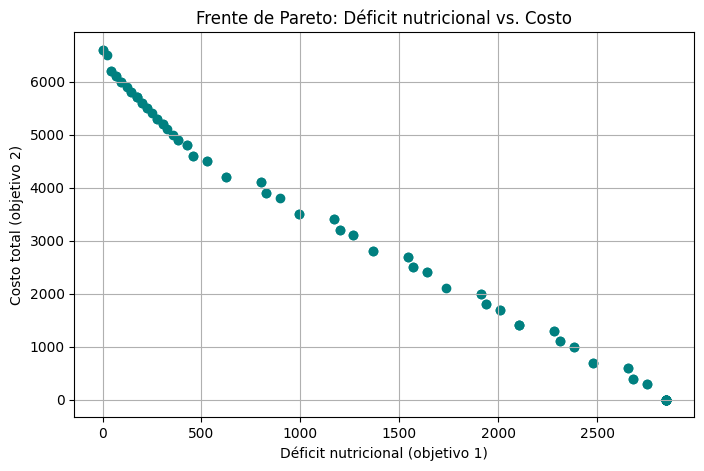

In [ ]:
# ============================================================
# Ejercicio 6: AG Multi-objetivo (NSGA-II) - Dieta con costo mínimo
# Librerías: numpy, pandas, matplotlib, DEAP (librería estándar de AG en Python)
# ============================================================

!pip install deap -q

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

# ---------- 1. Datos de alimentos (pandas) ----------
alimentos = pd.DataFrame([
    {"nombre": "Arroz",   "cal": 130, "prot": 2.7, "grasa": 0.3, "costo": 500},
    {"nombre": "Pollo",   "cal": 165, "prot": 31,  "grasa": 3.6, "costo": 2500},
    {"nombre": "Huevo",   "cal": 78,  "prot": 6.3, "grasa": 5.3, "costo": 400},
    {"nombre": "Lenteja", "cal": 116, "prot": 9,   "grasa": 0.4, "costo": 800},
    {"nombre": "Leche",   "cal": 42,  "prot": 3.4, "grasa": 1,   "costo": 600},
    {"nombre": "Papa",    "cal": 77,  "prot": 2,   "grasa": 0.1, "costo": 300},
    {"nombre": "Pan",     "cal": 265, "prot": 9,   "grasa": 3.2, "costo": 700},
    {"nombre": "Queso",   "cal": 402, "prot": 25,  "grasa": 33,  "costo": 3000},
    {"nombre": "Manzana", "cal": 52,  "prot": 0.3, "grasa": 0.2, "costo": 400},
    {"nombre": "Atún",    "cal": 132, "prot": 28,  "grasa": 1,   "costo": 2200},
])
N_ALIMENTOS = len(alimentos)
MAX_PORCIONES = 6

REQ_CAL, REQ_PROT, REQ_GRASA = 2000, 60, 50  # requerimientos mínimos diarios

# ---------- 2. Configuración DEAP: dos objetivos a MINIMIZAR ----------
# Objetivo 1: déficit nutricional | Objetivo 2: costo
if hasattr(creator, "FitnessMulti"):
    del creator.FitnessMulti
if hasattr(creator, "Individual"):
    del creator.Individual

creator.create("FitnessMulti", base.Fitness, weights=(-1.0, -1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()
toolbox.register("attr_porcion", random.randint, 0, MAX_PORCIONES)
toolbox.register("individual", tools.initRepeat, creator.Individual,
                  toolbox.attr_porcion, N_ALIMENTOS)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# ---------- 3. Función de evaluación (dos objetivos) ----------
def evaluar(ind):
    cal   = np.dot(ind, alimentos["cal"])
    prot  = np.dot(ind, alimentos["prot"])
    grasa = np.dot(ind, alimentos["grasa"])
    costo = np.dot(ind, alimentos["costo"])

    deficit_cal   = max(0, REQ_CAL - cal)
    deficit_prot  = max(0, REQ_PROT - prot) * 10
    deficit_grasa = max(0, REQ_GRASA - grasa) * 5
    exceso_cal    = max(0, cal - REQ_CAL * 1.3) * 0.5

    objetivo1_deficit_nutricional = deficit_cal + deficit_prot + deficit_grasa + exceso_cal
    objetivo2_costo = costo
    return objetivo1_deficit_nutricional, objetivo2_costo

toolbox.register("evaluate", evaluar)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt, low=0, up=MAX_PORCIONES, indpb=0.15)
toolbox.register("select", tools.selNSGA2)  # selección multi-objetivo (Frente de Pareto)

# ---------- 4. Ejecución del AG multi-objetivo ----------
random.seed(42)
TAM_POB, N_GEN = 100, 80

pop = toolbox.population(n=TAM_POB)
for ind in pop:
    ind.fitness.values = toolbox.evaluate(ind)

stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("min", np.min, axis=0)
stats.register("avg", np.mean, axis=0)

pop_final, log = algorithms.eaMuPlusLambda(
    pop, toolbox, mu=TAM_POB, lambda_=TAM_POB,
    cxpb=0.6, mutpb=0.3, ngen=N_GEN,
    stats=stats, verbose=True
)

# ---------- 5. Extraer el Frente de Pareto ----------
frente_pareto = tools.sortNondominated(pop_final, len(pop_final), first_front_only=True)[0]

resultados = []
for ind in frente_pareto:
    cal   = np.dot(ind, alimentos["cal"])
    prot  = np.dot(ind, alimentos["prot"])
    grasa = np.dot(ind, alimentos["grasa"])
    costo = np.dot(ind, alimentos["costo"])
    deficit, _ = ind.fitness.values
    resultados.append({"individuo": ind, "cal": cal, "prot": prot,
                        "grasa": grasa, "costo": costo, "deficit": deficit})

df_pareto = pd.DataFrame(resultados).sort_values("costo").reset_index(drop=True)
print("\n=== Frente de Pareto (soluciones no dominadas) ===")
print(df_pareto[["cal", "prot", "grasa", "costo", "deficit"]].round(2))

# ---------- 6. La solución más barata que además satisface la dieta ----------
factibles = df_pareto[df_pareto["deficit"] == 0]
if len(factibles) > 0:
    mejor = factibles.sort_values("costo").iloc[0]
    print("\n>>> Dieta de MENOR COSTO que SÍ cumple los requerimientos:")
else:
    mejor = df_pareto.sort_values("deficit").iloc[0]
    print("\n>>> Ninguna solución cumple 100% los requerimientos; se muestra la de menor déficit:")

for porciones, alim in zip(mejor["individuo"], alimentos["nombre"]):
    if porciones > 0:
        print(f"  {alim:10s}: {porciones} porción(es)")
print(f"Calorías: {mejor['cal']:.0f} | Proteínas: {mejor['prot']:.1f}g | "
      f"Grasas: {mejor['grasa']:.1f}g | Costo: ${mejor['costo']:.0f}")

# ---------- 7. Gráfica del Frente de Pareto (matplotlib) ----------
plt.figure(figsize=(8, 5))
plt.scatter(df_pareto["deficit"], df_pareto["costo"], c="teal")
plt.xlabel("Déficit nutricional (objetivo 1)")
plt.ylabel("Costo total (objetivo 2)")
plt.title("Frente de Pareto: Déficit nutricional vs. Costo")
plt.grid(True)
plt.show()